In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('data_science_job.csv')

In [7]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [10]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [11]:
df.shape

(19158, 13)

In [12]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]

In [13]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [14]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14851,0.624,no_enrollment,Graduate,0.0,102.0
9116,0.624,Full time course,Masters,3.0,30.0
8151,0.624,Full time course,Graduate,13.0,2.0
879,NaN,no_enrollment,Graduate,17.0,48.0
17965,0.915,no_enrollment,Graduate,20.0,75.0


In [35]:
df['enrolled_university'].value_counts()

,count
enrolled_university,
no_enrollment,13817
Full time course,3757
Part time course,1198


In [16]:
len(df[cols].dropna())  / len(df)

0.8968577095730244

In [17]:
new_df = df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

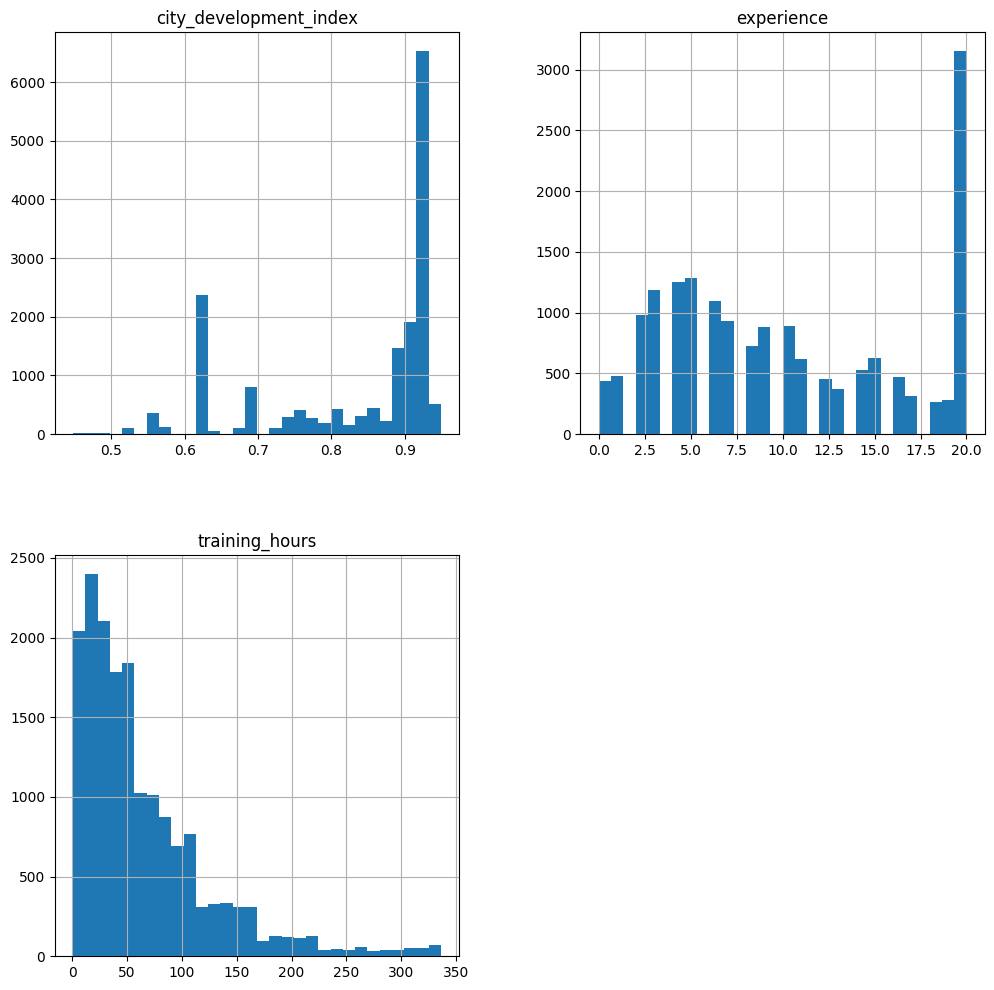

In [22]:
new_df.hist(bins=30,figsize=(12,12))

<Axes: >

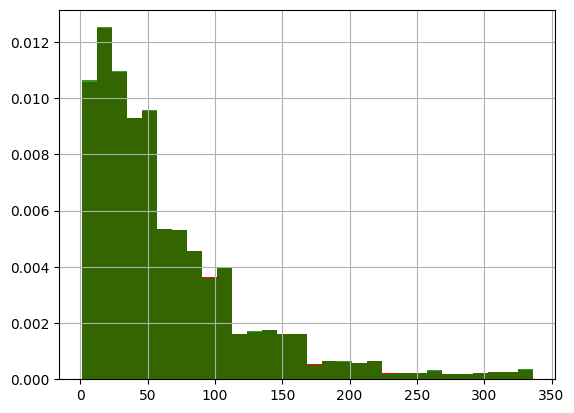

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# oraginal data
df['training_hours'].hist(bins=30,ax=ax,density=True,color='red')

# after applying CCA
new_df['training_hours'].hist(bins=30,ax=ax,density=True,color='green', alpha=0.8)

<Axes: ylabel='Density'>

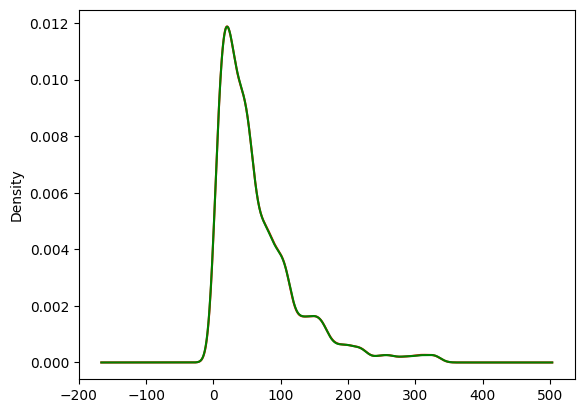

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111)

# oraginal data
df['training_hours'].plot.density(color='red')

# after applying CCA
new_df['training_hours'].plot.density(color='green')

<Axes: >

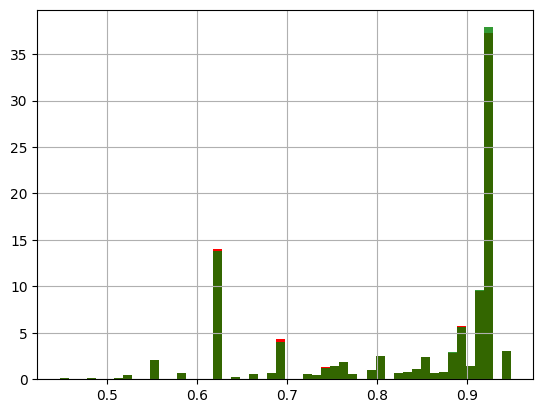

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

# oraginal data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# after applying CCA
new_df['city_development_index'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<Axes: ylabel='Density'>

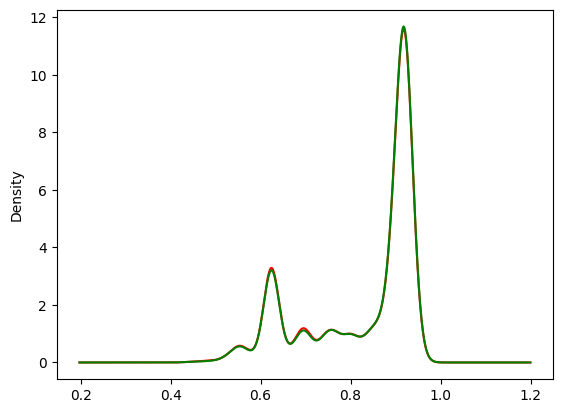

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111)

# oraginal data
df['city_development_index'].plot.density(color='red')

# after applying CCA
new_df['city_development_index'].plot.density(color='green')

<Axes: >

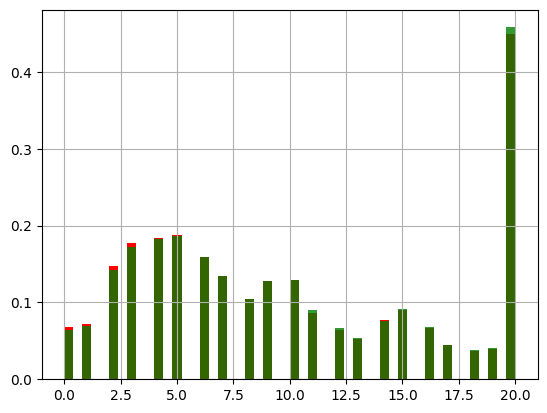

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

# oraginal data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# after applying CCA
new_df['experience'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<Axes: ylabel='Density'>

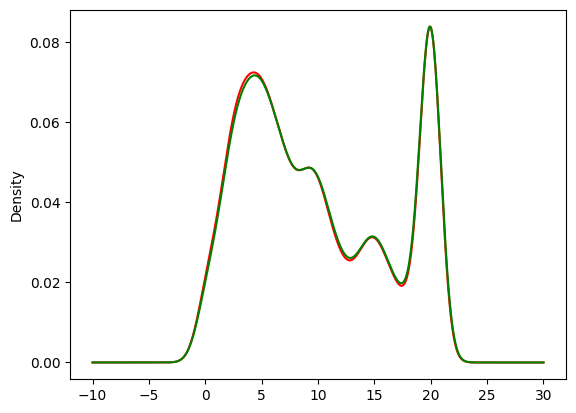

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)

# oraginal data
df['experience'].plot.density(color='red')


# after applying CCA
new_df['experience'].plot.density(color='green')

In [36]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(df)
], axis=1)
temp.columns = ['Original', 'cca']
temp


,Original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [37]:
temp = pd.concat([
    df['education_level'].value_counts() / len(df),
    new_df['education_level'].value_counts() / len(df)
], axis=1)
temp.columns = ['Original', 'cca']
temp


,Original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876
